# About This notebook

This notebook continues the Exploratory Data Analysis from the previous notebook. 

Here, we import data from the `stage_02` schema from the PostgreSQL database `train_reward_compare`. 

When finished, the notebook inserts the data into the next schema: `stage_03`.

## Links to Data

[https://www.onetcenter.org/database.html#all-files](https://www.onetcenter.org/database.html#all-files)

[https://www.bls.gov/oes/](https://www.bls.gov/oes/)

# Project Setup

## Import and Verifications

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sqlalchemy

In [2]:
print(sqlalchemy.__version__)
print(np.__version__)

2.0.48
2.1.0


In [3]:
from sqlalchemy import create_engine, inspect
from sqlalchemy import text
from sqlalchemy.schema import CreateSchema
from sqlalchemy import BigInteger, Column, Integer, String, Float, Boolean, Text, Date
from sqlalchemy.orm import DeclarativeBase, Mapped, mapped_column

In [4]:
# The following imports are a match from the previous Springboard EDA project

import statsmodels.api as sm
from statsmodels.graphics.api import abline_plot
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn import linear_model, preprocessing
import warnings
from sklearn.preprocessing import StandardScaler
 
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.filterwarnings(action="ignore", module="scipy", message="^internal gelsd")

## Create SQL Engine and Test Connection

In [5]:
engine = create_engine('postgresql+psycopg2://postgres@localhost/train_reward_compare')

In [6]:
with engine.connect() as conn:
    result = conn.execute(text("select count(*) from onet.occupation_data"))
    print(result.fetchone())

(1016,)


# Import Data from PostgreSQL

## List of Imports

We start by bringing the previous dataset stored in the `stage_02` schema.

- df

## Import Dataset

In [7]:
# Data Schema for Import
schema_name_import = 'stage_02'

# Data Table Names
df_table_name = 'df'

In [8]:
full_df = pd.DataFrame()

with engine.connect() as conn:
    df = pd.read_sql_table(df_table_name, schema=schema_name_import, con=engine, index_col='id')

In [9]:
df.head()

,onetsoc_code,education_sum,occ_code,accepted_title,a_mean
id,,,,,
1,29-1221,1177.03,29-1221,"Pediatricians, General",222340.0
2,29-1218,1170.56,29-1218,Obstetricians and Gynecologists,281130.0
3,29-1022,1164.24,29-1022,Oral and Maxillofacial Surgeons,360240.0
4,29-1211,1160.55,29-1211,Anesthesiologists,336640.0
5,29-1214,1158.62,29-1214,Emergency Medicine Physicians,320700.0


# Prepping Data

## Dropping `onetsoc_code`

We've come now to the stage where we need to prepare to create dummy columns.

The primary categories that we wish to observe are the `major` and `minor` groups. Those are determined respectively by the first two digits and the first four digits (excluding the hyphen) of the associated code.

We've kept both the O*NET code and the BLS code up to this point.

The differences between these two columns are limited strictly to the minutiae of the `broad` and `detailed` subgroups, which are not within the scope of our categories.

Therefore, we'll drop the `onetsoc_code` from the O*NET dataset and keep only `occ_code'.

In [10]:
df = df.drop(columns=['onetsoc_code'])

## Creating Dummy Variables

Let's create two new columns: one for the `major` categories and one for the `minor` categories.

In [11]:
df['major'] = df['occ_code'].str[:2]

In [12]:
df['minor'] = df['occ_code'].str[:5]

In [13]:
df.head()

,education_sum,occ_code,accepted_title,a_mean,major,minor
id,,,,,,
1,1177.03,29-1221,"Pediatricians, General",222340.0,29,29-12
2,1170.56,29-1218,Obstetricians and Gynecologists,281130.0,29,29-12
3,1164.24,29-1022,Oral and Maxillofacial Surgeons,360240.0,29,29-10
4,1160.55,29-1211,Anesthesiologists,336640.0,29,29-12
5,1158.62,29-1214,Emergency Medicine Physicians,320700.0,29,29-12


Let's perform one-hot encoding by creating dummy variables. 

In [14]:
df_d = pd.get_dummies(df, columns=['major', 'minor'], prefix='')

In [15]:
df_d.columns = df_d.columns.astype(str)

In [16]:
df_d.head()

,education_sum,occ_code,accepted_title,a_mean,_11,_13,_15,_17,_19,_21,...,_51-90,_51-91,_53-10,_53-20,_53-30,_53-40,_53-50,_53-60,_53-70,_53-71
id,,,,,,,,,,,,,,,,,,,,,
1,1177.03,29-1221,"Pediatricians, General",222340.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1170.56,29-1218,Obstetricians and Gynecologists,281130.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1164.24,29-1022,Oral and Maxillofacial Surgeons,360240.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1160.55,29-1211,Anesthesiologists,336640.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,1158.62,29-1214,Emergency Medicine Physicians,320700.0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Train, Test, Split

As noted above, there is a positive linear relationship between the two variables, `education_sum` and `a_mean`.

We now divide the data into training and test sets and create a prediction model.

In [17]:
X = pd.DataFrame(df_d.drop(columns=['a_mean']))
y = pd.DataFrame(df_d['a_mean'])

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [19]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(547, 134)
(183, 134)
(547, 1)
(183, 1)


## Implementing a Scalar

In [20]:
scaler = StandardScaler()

In [21]:
scaler.fit(X_train[['education_sum']])

,copy,True
,with_mean,True
,with_std,True


In [22]:
X_train['scaled_ed_sum'] = scaler.transform(X_train[['education_sum']])

In [23]:
X_test['scaled_ed_sum'] = scaler.transform(X_test[['education_sum']])

# Modeling

## Linear Regression Model

### Make the Linear Regression Model

In [24]:
rModel = linear_model.LinearRegression()

In [29]:
X_train.columns

Index(['education_sum', 'occ_code', 'accepted_title', '_11', '_13', '_15',
       '_17', '_19', '_21', '_23',
       ...
       '_51-91', '_53-10', '_53-20', '_53-30', '_53-40', '_53-50', '_53-60',
       '_53-70', '_53-71', 'scaled_ed_sum'],
      dtype='object', length=135)

In [28]:
rModel.fit(X_train, y_train)

AttributeError: 'DataFrame' object has no attribute 'dtype'

### Evaluate the Model

In [55]:
y_pred = rModel.predict(X_train)

In [56]:
r2 = r2_score(y_train, y_pred)

In [57]:
print(r2)

0.3975965265992558


At the moment, our model explains only 39.8% of the variation.

### Refining the Model

Let's continue refining according to the techniques we learned at Springboard.

In [58]:
y_pred.shape

(547, 1)

#### Plot the Predictions vs the Actual

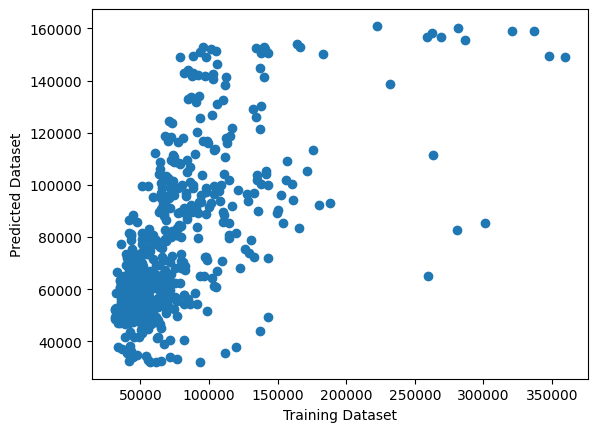

In [60]:
_ = plt.scatter(x=y_train, y=y_pred)
_ = plt.xlabel('Training Dataset')
_ = plt.ylabel('Predicted Dataset')
plt.show()

There is a visible positive correlation, but the is room for improvement.

For example, actual values of `250000` were predicted to have only `60000`.

## Ordinary Least Squares Model

We try another type of regression model: Ordinary Least Squares.

### Set Up the Data

In [61]:
X_ols = pd.DataFrame(df['education_sum'])
X_ols = sm.add_constant(X_ols)

In [62]:
y_ols = pd.DataFrame(df['a_mean'])

In [63]:
X_ols_train, X_ols_test, y_ols_train, y_ols_test = train_test_split(X_ols, y_ols, test_size=0.25, random_state=42)

### Train the Model

In [64]:
rModel_ols = sm.OLS(y_ols_train, X_ols_train).fit()

### Evaluate the Model

In [65]:
rModel_ols.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 a_mean   R-squared:                       0.398
Model:                            OLS   Adj. R-squared:                  0.396
Method:                 Least Squares   F-statistic:                     359.7
Date:                Sat, 02 May 2026   Prob (F-statistic):           5.65e-62
Time:                        10:11:50   Log-Likelihood:                -6523.0
No. Observations:                 547   AIC:                         1.305e+04
Df Residuals:                     545   BIC:                         1.306e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          3.216e+04   2823.685     11.391      0.000    2.66e+04    3.77e+04
education_sum   109.4059      5.769     18.966      0.000      98.075     120.737
==============================================================================
Omnibus:                      327.397   Durbin-Watson:                   1.926
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2956.219
Skew:                           2.541   Prob(JB):                         0.00
Kurtosis:                      13.193   Cond. No.                         883.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

#### Commentary

The condition number is not large.

The r-squared value is the same as before, 39.8%.

### Use the Model to Make Predictions

In [66]:
y_ols_predict = rModel_ols.predict(X_ols_test)

In [67]:
y_ols_predict.head()

5572     60238.115807
1775    100405.387830
3605     75075.740233
4240     68164.571268
6129     57285.251309
dtype: float64

### Plot Predictions

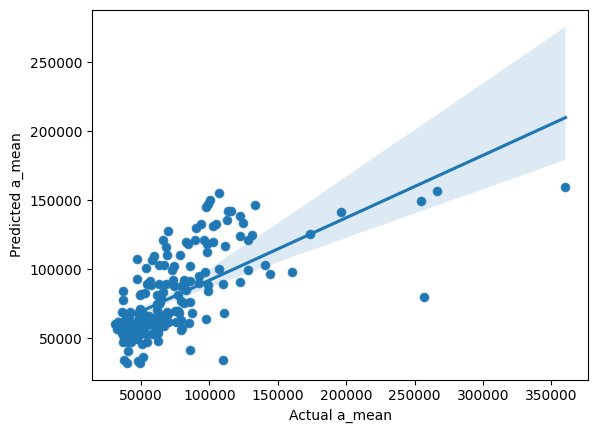

In [68]:
_ = sns.scatterplot(x=y_ols_test['a_mean'], y=y_ols_predict)
_ = sns.regplot(x=y_ols_test['a_mean'], y=y_ols_predict)
_.set(xlabel='Actual a_mean', ylabel='Predicted a_mean')
plt.show()

The overall effect seems not to have improved.

# Conclusions

There is a positive correlation between the value respondents place on higher levels of education and an increase in average annual salary.

However, while the linear-regression model is useful, there is not a definitive correlation.

This is logical, because some careers require skills that are difficult to teach, if not impossible. For example, CEOs require more than just mathematical learning; they require leadership, which is a truly difficult concept to translate into a classroom curriculum.

Another example can be found with sports athletes. Professional athletes make exorbant amounts of income, but may not need an education beyond high school.

Therefore, education does seem to have value overall, but it is not a decisive factor in an individual person's earning potential.